In [2]:
import control as ctrl
import matplotlib.pyplot as plt
import math
import numpy as np

## Ej 5

In [3]:
Aa = np.array([
    [-0.25, -2.00,  0.0, 0.0],
    [ 0.08, -0.35,  0.0, 0.0],
    [ 0.00,  1.00,  0.0, 0.0],
    [ 0.00,  0.00, -1.0, 0.0]
])

Ba = np.array([
    [0.0],
    [0.62],
    [0.0],
    [0.0]
])

n = Aa.shape[0]

Mc = np.hstack([
    Ba,
    Aa @ Ba,
    np.linalg.matrix_power(Aa, 2) @ Ba,
    np.linalg.matrix_power(Aa, 3) @ Ba
])

phi_A = (
    np.linalg.matrix_power(Aa, 4)
    + 9.0 * np.linalg.matrix_power(Aa, 3)
    + 29.75 * np.linalg.matrix_power(Aa, 2)
    + 42.75 * Aa
    + 22.5 * np.eye(n)
)

e_n = np.array([[0.0, 0.0, 0.0, 1.0]])

Ka = e_n @ np.linalg.inv(Mc) @ phi_A
Aa_lc = Aa - Ba @ Ka

print("\nKa:")
print(Ka)
print("\nMatriz A a lazo cerrado:")
print(Aa_lc)
print("\nPolos a lazo cerrado:")
print(np.linalg.eigvals(Aa_lc))


Ka:
[[-174.51814516   13.5483871  -304.83870968 -145.16129032]]

Matriz A a lazo cerrado:
[[ -0.25     -2.        0.        0.     ]
 [108.28125  -8.75    189.       90.     ]
 [  0.        1.        0.        0.     ]
 [  0.        0.       -1.        0.     ]]

Polos a lazo cerrado:
[-3.  -2.5 -2.  -1.5]


## EJ 6

In [4]:
Ca = np.array([[0.0, 0.0, 1.0, 0.0]])
Da = np.array([[0.0]])
Br = np.array([[0.0], [0.0], [0.0], [1.0]])

# La referencia entra en el integrador: x4_dot = psi_ref - psi.
sistema_lc = ctrl.ss(Aa_lc, Br, Ca, Da)
Gs = ctrl.ss2tf(sistema_lc)

print("G(s) a lazo cerrado:")
print(Gs)

G(s) a lazo cerrado:
<TransferFunction>: sys[1]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        8.882e-15 s^3 + 90 s + 22.5
  ----------------------------------------
  s^4 + 9 s^3 + 29.75 s^2 + 42.75 s + 22.5


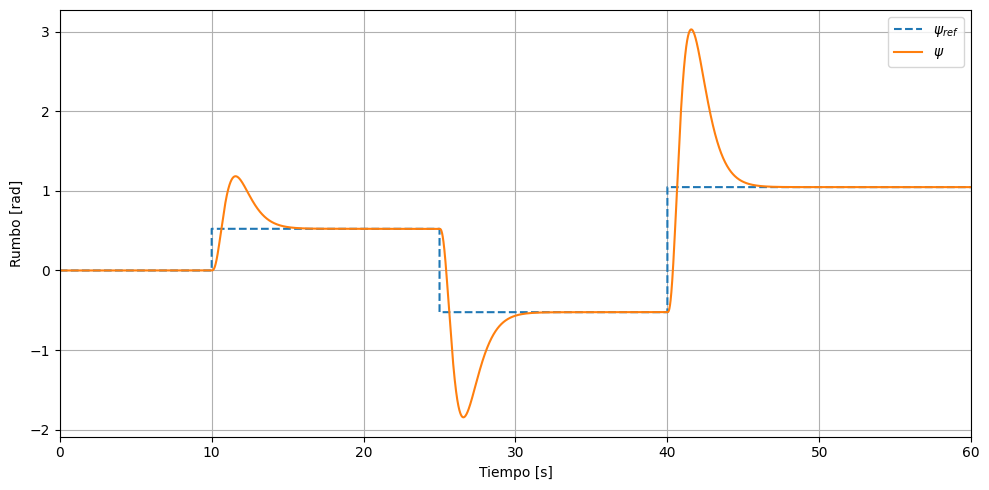

In [5]:
Tf = 60.0
dt = 0.01
t = np.arange(0.0, Tf + dt, dt)

psi_ref = np.select(
    [t < 10.0, t < 25.0, t < 40.0],
    [0.0, np.pi / 6.0, -np.pi / 6.0],
    default=np.pi / 3.0,
)

respuesta = ctrl.forced_response(sistema_lc, T=t, U=psi_ref)
psi = np.asarray(respuesta.outputs).squeeze()

plt.figure(figsize=(10, 5))
plt.step(t, psi_ref, where="post", linestyle="--", label=r"$\psi_{ref}$")
plt.plot(t, psi, label=r"$\psi$")
plt.xlabel("Tiempo [s]")
plt.ylabel("Rumbo [rad]")
plt.xlim(0.0, Tf)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Ej 7

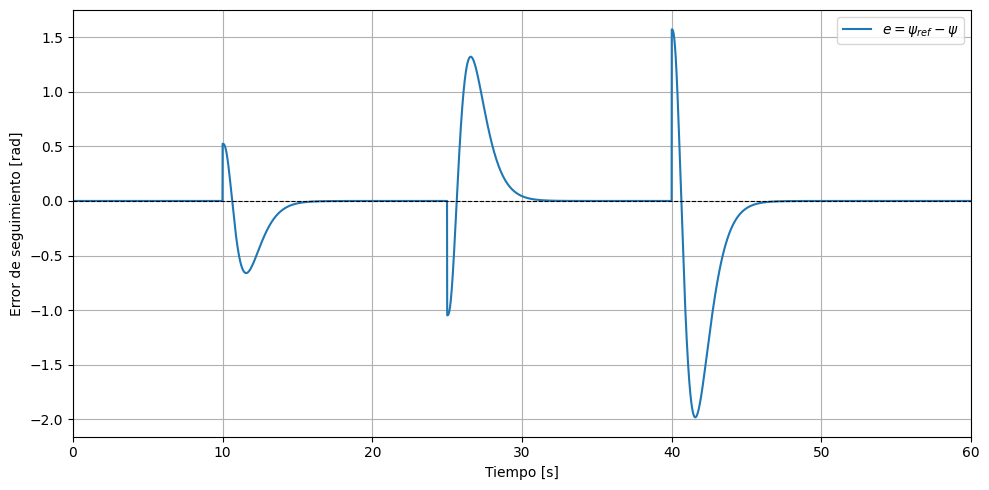

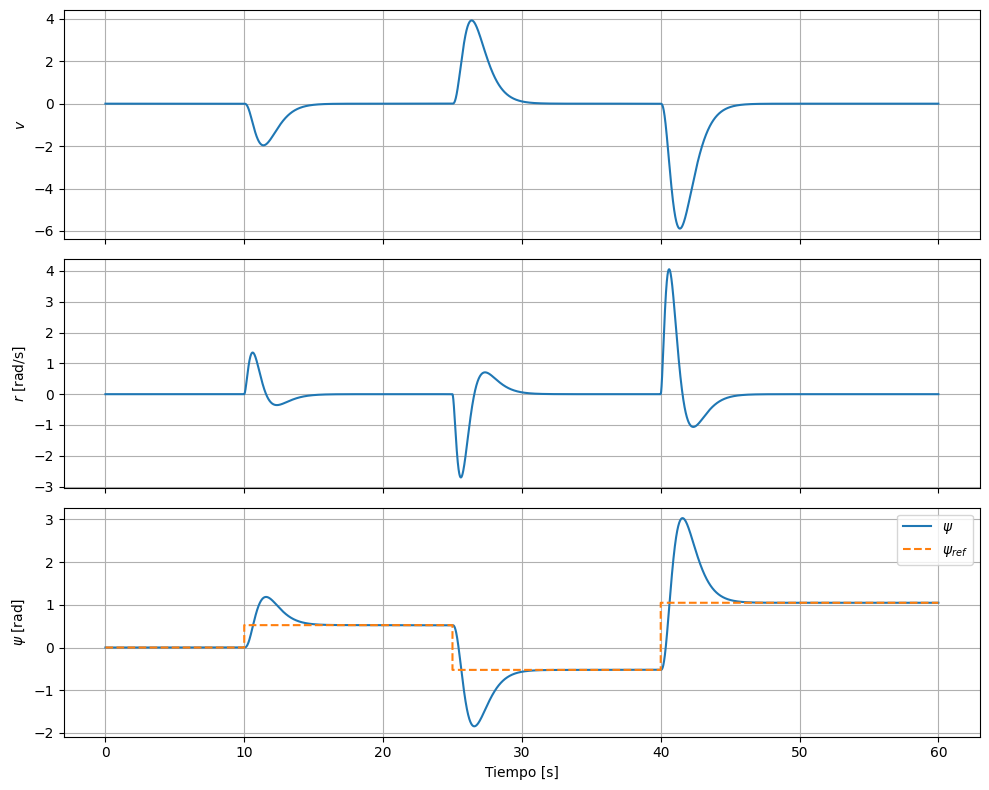

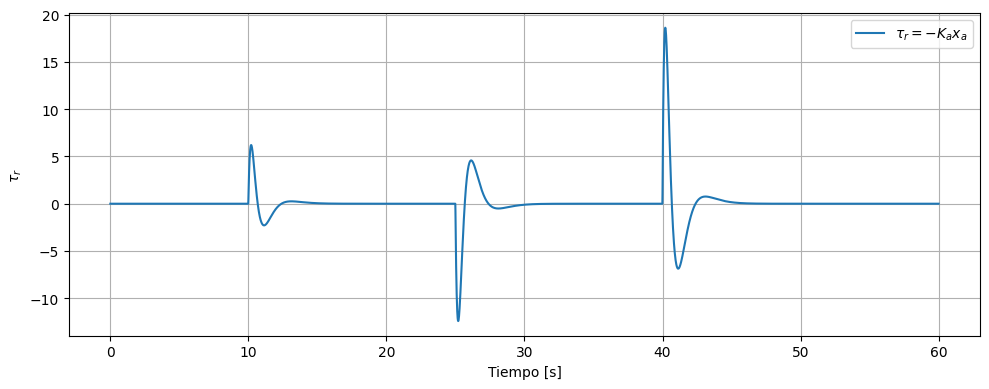

In [6]:
Tf = 60.0
dt = 0.01
t = np.arange(0.0, Tf + dt, dt)

psi_ref = np.select(
    [t < 10.0, t < 25.0, t < 40.0],
    [0.0, np.pi / 6.0, -np.pi / 6.0],
    default=np.pi / 3.0,
)

respuesta = ctrl.forced_response(sistema_lc, T=t, U=psi_ref)
psi = np.asarray(respuesta.outputs).squeeze()
x = np.asarray(respuesta.states)
v = x[0, :]
r = x[1, :]
psi = x[2, :]
x_integral = x[3, :]

err = psi_ref - psi
t_r = np.asarray(-Ka @ x).squeeze()

plt.figure(figsize=(10, 5))
plt.plot(t, err, label=r"$e=\psi_{ref}-\psi$")
plt.axhline(0.0, color="black", linestyle="--", linewidth=0.8)

plt.xlabel("Tiempo [s]")
plt.ylabel("Error de seguimiento [rad]")
plt.xlim(0.0, Tf)
plt.grid(True)
plt.legend()
plt.tight_layout()

fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax[0].plot(t, v)
ax[0].set_ylabel(r"$v$")
ax[0].grid(True)

ax[1].plot(t, r)
ax[1].set_ylabel(r"$r$ [rad/s]")
ax[1].grid(True)

ax[2].plot(t, psi, label=r"$\psi$")
ax[2].step(t, psi_ref, where="post", linestyle="--",
           label=r"$\psi_{ref}$")
ax[2].set_ylabel(r"$\psi$ [rad]")
ax[2].set_xlabel("Tiempo [s]")
ax[2].grid(True)
ax[2].legend()

plt.figure(figsize=(10, 4))
plt.plot(t, t_r, label=r"$\tau_r=-K_ax_a$")
plt.xlabel("Tiempo [s]")
plt.ylabel(r"$\tau_r$")
plt.grid(True)
plt.legend()
plt.tight_layout()

fig.tight_layout()


plt.show()

# Parte B

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

## Ej 2

In [10]:
u0 = 2.0

v_interp = interp1d(t, v, kind="linear", fill_value="extrapolate")
psi_interp = interp1d(t, psi, kind="linear", fill_value="extrapolate")

def cinematica_xy(ti, pos):
    X, Y = pos

    v_t = float(v_interp(ti))
    psi_t = float(psi_interp(ti))

    X_dot = u0 * np.cos(psi_t) - v_t * np.sin(psi_t)
    Y_dot = u0 * np.sin(psi_t) + v_t * np.cos(psi_t)

    return [X_dot, Y_dot]

pos0 = [0.0, 0.0]

sol_xy = solve_ivp(
    cinematica_xy,
    [t[0], t[-1]],
    pos0,
    t_eval=t
)

X = sol_xy.y[0]
Y = sol_xy.y[1]


## Ej 3

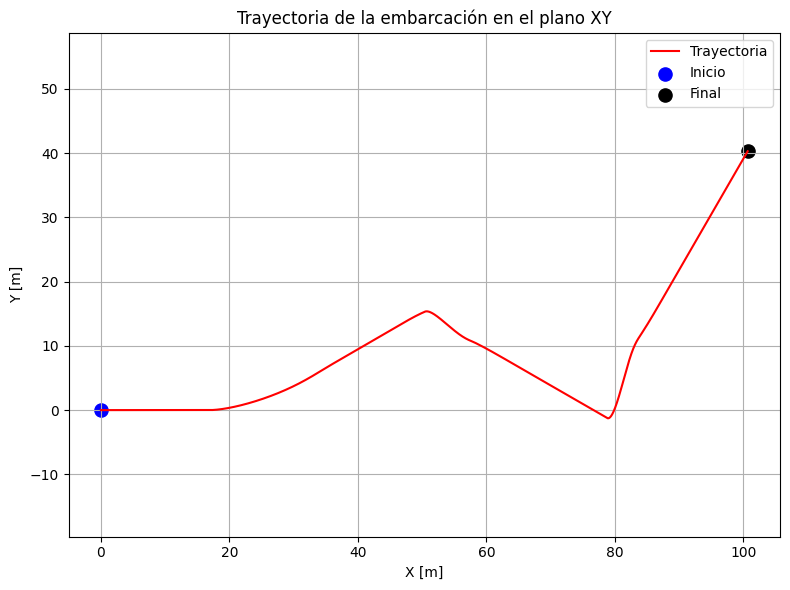

In [11]:
plt.figure(figsize=(8, 6))

plt.plot(X, Y, color="red", linewidth=1.5, label="Trayectoria")
plt.scatter(X[0], Y[0], color="blue", s=90, label="Inicio")
plt.scatter(X[-1], Y[-1], color="black", s=90, label="Final")

plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.title("Trayectoria de la embarcación en el plano XY")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Parte C

In [ ]:
# Más agresivo: sigue mejor, pero usa más control
Qa = np.diag([1, 1, 100, 300])
R = np.array([[0.5]])

# Más suave: usa menos control, pero responde más lento
Qa = np.diag([1, 5, 50, 100])
R = np.array([[10]])

# Compromiso
Qa = np.diag([1, 2, 80, 200])
R = np.array([[3]])

def funcion_costo(x_a, u, Q,R):
    return x_a.T @ Q @ x_a +  u.T @ R @ u

costos = []
for i in range(len(t)):
    x_a_i = np.array([[v[i]],
                      [r[i]],
                      [psi[i]],
                      [x_integral[i]]])

    tau_r_i = float(-Ka @ x_a_i)
    u_i = np.array([[tau_r_i]])

    costos.append(funcion_costo(x_a_i, u_i, Qa, R))

J = np.trapz(costos, t)
sol_xy = solve_ivp(
    cinematica_xy,
    [t[0], t[-1]],
    pos0,
    t_eval=t
)

/tmp/ipykernel_535427/118225866.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  tau_r_i = float(-Ka @ x_a_i)
/tmp/ipykernel_535427/118225866.py:28: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  J = np.trapz(costos, t)


ValueError: operands could not be broadcast together with shapes (1,1,6000) (6001,1,0) 